In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [3]:
train_df = pd.read_csv("train_energy_data.csv")
test_df = pd.read_csv("test_energy_data.csv")

In [4]:
print("Train Data:")
print(train_df.head())

Train Data:
  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential            7063                   76               10   
1    Commercial           44372                   66               45   
2    Industrial           19255                   37               17   
3   Residential           13265                   14               41   
4    Commercial           13375                   26               18   

   Average Temperature Day of Week  Energy Consumption  
0                29.84     Weekday             2713.95  
1                16.72     Weekday             5744.99  
2                14.30     Weekend             4101.24  
3                32.82     Weekday             3009.14  
4                11.92     Weekday             3279.17  


In [5]:
print("Test Data:")
print(test_df.head())

Test Data:
  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential           24563                   15                4   
1    Commercial           27583                   56               23   
2    Commercial           45313                    4               44   
3   Residential           41625                   84               17   
4   Residential           36720                   58               47   

   Average Temperature Day of Week  Energy Consumption  
0                28.52     Weekday             2865.57  
1                23.07     Weekend             4283.80  
2                33.56     Weekday             5067.83  
3                27.39     Weekend             4624.30  
4                17.08     Weekday             4820.59  


In [6]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1000, 7)
Test Shape: (100, 7)


In [7]:
print("Columns:")
print(train_df.columns)

Columns:
Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')


In [8]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB
None


In [9]:
print("Numerical Summary:")
print(train_df.describe())

Numerical Summary:
       Square Footage  Number of Occupants  Appliances Used  \
count        1000.000          1000.000000      1000.000000   
mean        25462.388            48.372000        25.606000   
std         14294.554            29.061972        14.105166   
min           560.000             1.000000         1.000000   
25%         13169.750            22.000000        13.000000   
50%         25477.000            47.000000        26.000000   
75%         37446.250            73.250000        38.000000   
max         49997.000            99.000000        49.000000   

       Average Temperature  Energy Consumption  
count          1000.000000         1000.000000  
mean             22.611390         4166.252570  
std               7.139943          933.313064  
min              10.050000         1683.950000  
25%              16.475000         3509.482500  
50%              22.815000         4175.730000  
75%              28.850000         4863.850000  
max              34.9

In [10]:
print("Missing Values:")
print(train_df.isnull().sum())

Missing Values:
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64


In [11]:
print("\nDuplicate Rows:", train_df.duplicated().sum())


Duplicate Rows: 0


In [12]:
# Separate numerical & categorical columns
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = train_df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Square Footage', 'Number of Occupants', 'Appliances Used',
       'Average Temperature', 'Energy Consumption'],
      dtype='object')
Categorical Columns: Index(['Building Type', 'Day of Week'], dtype='object')


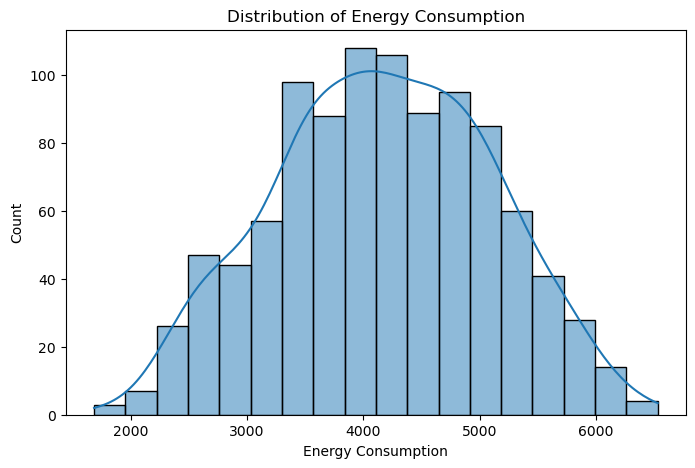

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['Energy Consumption'], kde=True)
plt.title("Distribution of Energy Consumption")
plt.show()

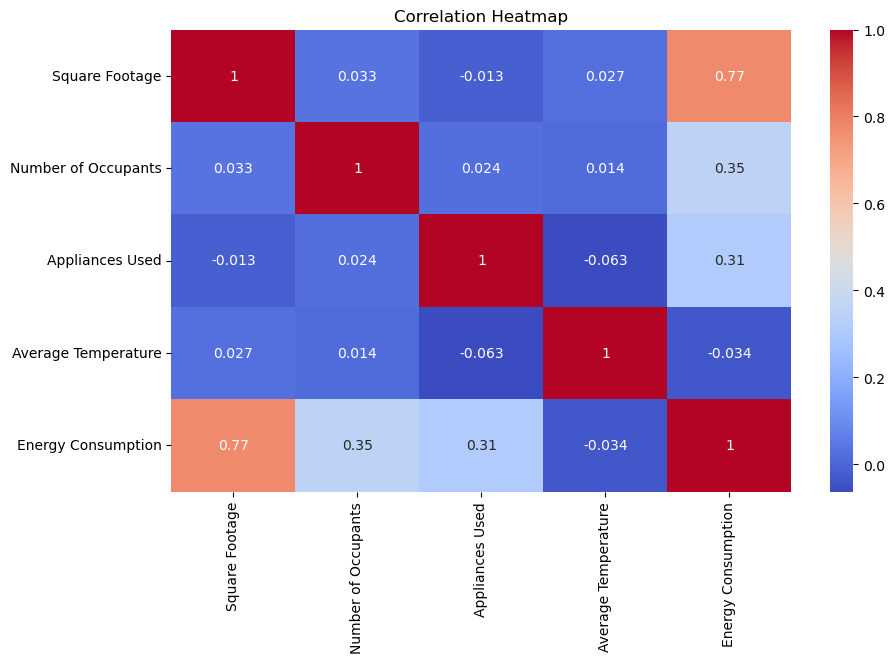

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(train_df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

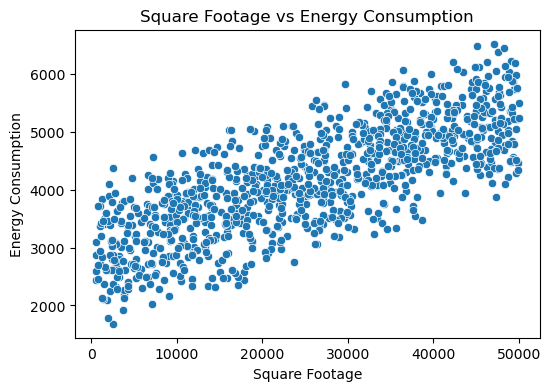

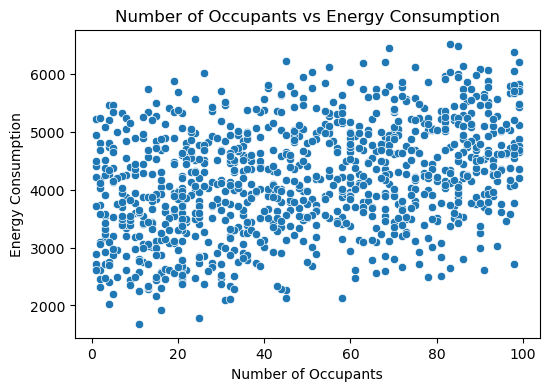

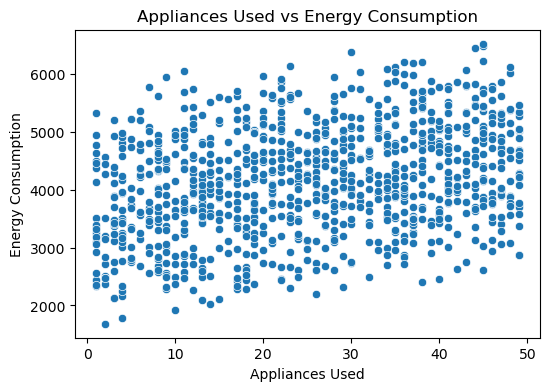

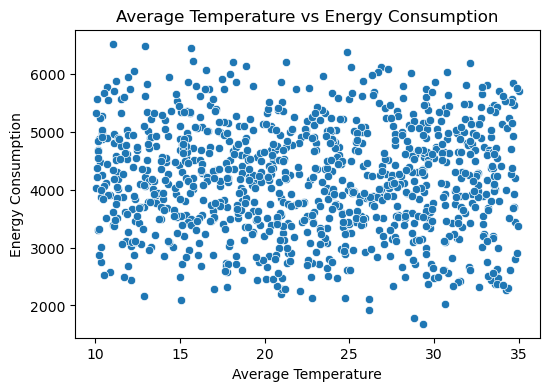

In [15]:
for col in num_cols:
    if col != 'Energy Consumption':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=train_df[col], y=train_df['Energy Consumption'])
        plt.title(f"{col} vs Energy Consumption")
        plt.show()

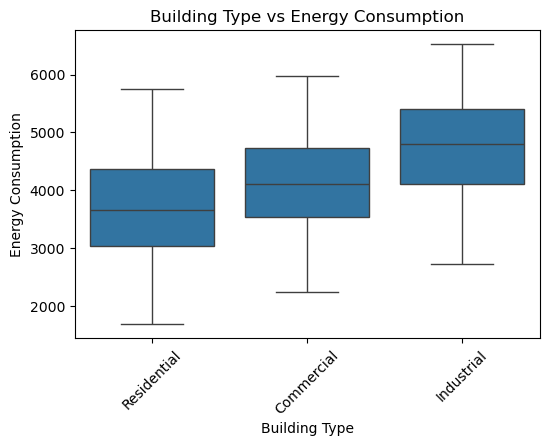

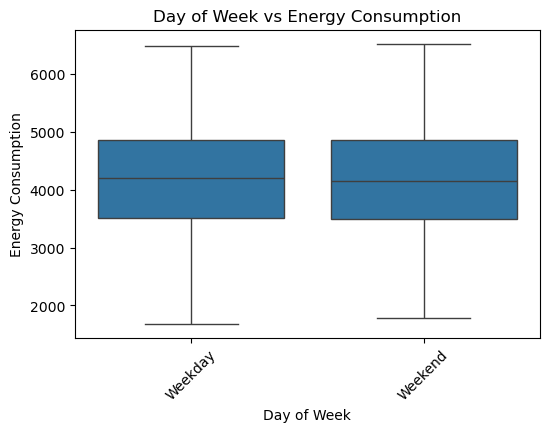

In [16]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=train_df[col], y=train_df['Energy Consumption'])
    plt.title(f"{col} vs Energy Consumption")
    plt.xticks(rotation=45)
    plt.show()

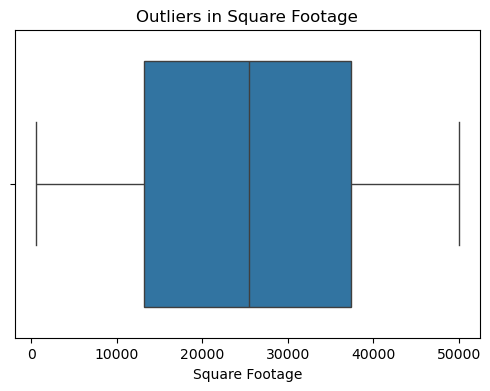

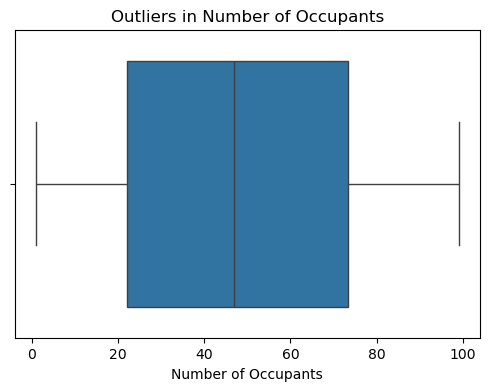

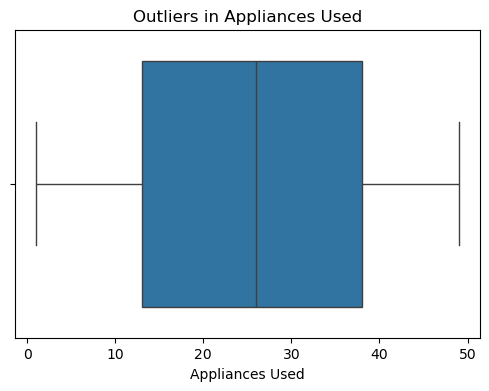

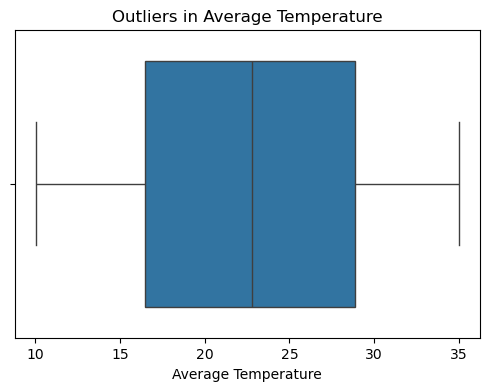

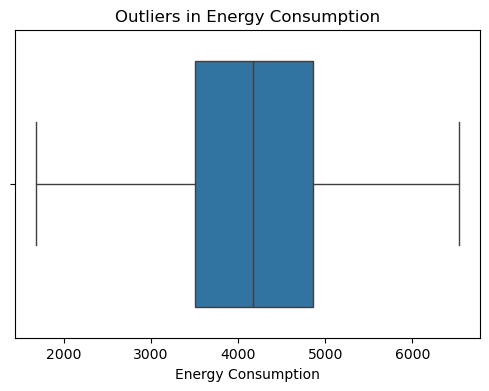

In [17]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=train_df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [18]:
# define features and target
X = train_df.drop("Energy Consumption", axis=1)
y = train_df["Energy Consumption"]

In [19]:
# split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (800, 6)
X_val shape: (200, 6)
y_train shape: (800,)
y_val shape: (200,)


In [21]:
encoders = {}

cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    encoders[col] = le

for col in cat_cols:
    X_val[col] = encoders[col].transform(X_val[col])

In [22]:
print(X_train.head())
print(X_train.dtypes)

     Building Type  Square Footage  Number of Occupants  Appliances Used  \
29               2           27072                   12               30   
535              0            9874                    5               19   
695              1           22427                    8               13   
557              2           30129                   29               33   
836              0           16350                   14               38   

     Average Temperature  Day of Week  
29                 32.89            1  
535                20.65            0  
695                26.21            0  
557                23.73            1  
836                18.39            0  
Building Type            int64
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week              int64
dtype: object


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [24]:
## Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [26]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_val_scaled)

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_val, y_pred_lr))
print("R2 Score:", r2_score(y_val, y_pred_lr))

Linear Regression:
MAE: 330.37436517125417
R2 Score: 0.8451931910305853


In [27]:
## Random Forest

In [28]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_val, y_pred_rf))
print("R2 Score:", r2_score(y_val, y_pred_rf))


Random Forest:
MAE: 109.35550150000009
R2 Score: 0.9775554158463345


In [29]:
# training prediction
y_train_pred = rf.predict(X_train)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Validation R2:", r2_score(y_val, y_pred_rf))

Train R2: 0.9968903065501697
Validation R2: 0.9775554158463345


In [30]:
## Cross Validation with Tuned Random Forest

In [31]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor

In [32]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [33]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')

print("R2 scores for each fold:", cv_r2)
print("Average R2 score:", cv_r2.mean())

R2 scores for each fold: [0.96384687 0.96947559 0.98129488 0.96857288 0.96957694]
Average R2 score: 0.9705534329398464


In [34]:
cv_mae = cross_val_score(rf, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')

print("MAE scores for each fold:", -cv_mae)
print("Average MAE score:", -cv_mae.mean())

MAE scores for each fold: [130.50063093 124.90844393 115.23409963 127.71657043 128.60310759]
Average MAE score: 125.39257050102033


In [35]:
# Final Model (Tuned Random Forest)

rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_final.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

In [36]:
y_pred_final = rf_final.predict(X_val)

print("Final Model Performance:")
print("MAE:", mean_absolute_error(y_val, y_pred_final))
print("R2 Score:", r2_score(y_val, y_pred_final))

Final Model Performance:
MAE: 114.26500547686501
R2 Score: 0.9755601791899201


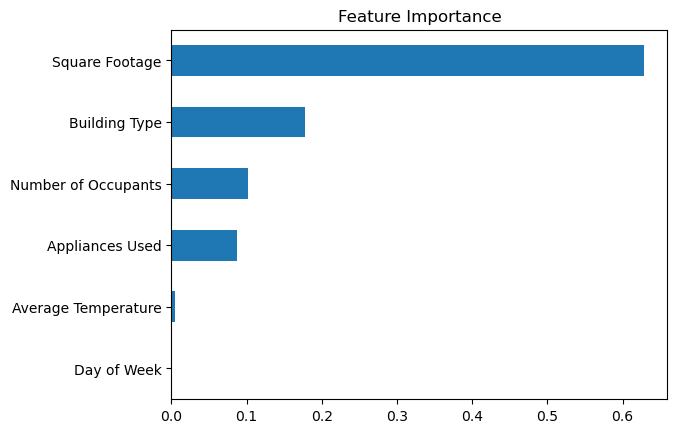

In [37]:
import pandas as pd

importance = rf_final.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [38]:
# reload fresh test data
test_df = pd.read_csv("test_energy_data.csv")

# create fresh X_test
X_test = test_df.drop("Energy Consumption", axis=1, errors="ignore")

print(X_test.head())
print(X_test.dtypes)

  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential           24563                   15                4   
1    Commercial           27583                   56               23   
2    Commercial           45313                    4               44   
3   Residential           41625                   84               17   
4   Residential           36720                   58               47   

   Average Temperature Day of Week  
0                28.52     Weekday  
1                23.07     Weekend  
2                33.56     Weekday  
3                27.39     Weekend  
4                17.08     Weekday  
Building Type           object
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week             object
dtype: object


In [39]:
# make test features same as training features
X_test = test_df.drop("Energy Consumption", axis=1, errors="ignore")

print(X_test.columns)

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week'],
      dtype='object')


In [40]:
# check unseen categories in test data
for col in encoders:
    train_classes = set(encoders[col].classes_)
    test_values = set(X_test[col].astype(str).unique())
    unseen = test_values - train_classes
    
    print(f"{col} -> Unseen values: {unseen}")

Building Type -> Unseen values: set()
Day of Week -> Unseen values: set()


In [41]:
# reload fresh test data
test_df = pd.read_csv("test_energy_data.csv")

# create clean test features
X_test = test_df.drop("Energy Consumption", axis=1, errors="ignore")

print(X_test.head())
print(X_test.dtypes)

  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential           24563                   15                4   
1    Commercial           27583                   56               23   
2    Commercial           45313                    4               44   
3   Residential           41625                   84               17   
4   Residential           36720                   58               47   

   Average Temperature Day of Week  
0                28.52     Weekday  
1                23.07     Weekend  
2                33.56     Weekday  
3                27.39     Weekend  
4                17.08     Weekday  
Building Type           object
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week             object
dtype: object


In [42]:
# reload fresh test data
test_df = pd.read_csv("test_energy_data.csv")

# create clean test features
X_test = test_df.drop("Energy Consumption", axis=1, errors="ignore")

print(X_test.head())
print(X_test.dtypes)

  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential           24563                   15                4   
1    Commercial           27583                   56               23   
2    Commercial           45313                    4               44   
3   Residential           41625                   84               17   
4   Residential           36720                   58               47   

   Average Temperature Day of Week  
0                28.52     Weekday  
1                23.07     Weekend  
2                33.56     Weekday  
3                27.39     Weekend  
4                17.08     Weekday  
Building Type           object
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week             object
dtype: object


In [43]:
# encode clean test data using saved encoders
for col in encoders:
    X_test[col] = encoders[col].transform(X_test[col])

print(X_test.head())
print(X_test.dtypes)

   Building Type  Square Footage  Number of Occupants  Appliances Used  \
0              2           24563                   15                4   
1              0           27583                   56               23   
2              0           45313                    4               44   
3              2           41625                   84               17   
4              2           36720                   58               47   

   Average Temperature  Day of Week  
0                28.52            0  
1                23.07            1  
2                33.56            0  
3                27.39            1  
4                17.08            0  
Building Type            int64
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week              int64
dtype: object


In [44]:
# final prediction on test data
test_predictions = rf_final.predict(X_test)

print(test_predictions[:10])

[3031.17391849 4372.04951023 5236.49976266 4732.32602313 4605.8643338
 4995.96460083 4549.81395433 2423.32462    4002.84578449 4903.10139857]


In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_final.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

In [50]:
import joblib

joblib.dump(rf_final, "energy_model.pkl")
joblib.dump(encoders, "encoders.pkl")

print("Both files saved!")

Both files saved!


In [51]:
import joblib

joblib.dump(rf_final, "energy_model.pkl")
joblib.dump(encoders, "encoders.pkl")

print("Model saved successfully!")

Model saved successfully!


In [52]:
import os

print(os.getcwd())   # shows current folder
print(os.listdir())  # shows all files in that folder

C:\Users\DELL\Documents\python code\machine learning
['.ipynb_checkpoints', '19sep.ipynb', 'Adult income prediction(ML).ipynb', 'adult.csv', 'customer_clustering_dataset.xlsx', 'encoders.pkl', 'Energy consumption(1).ipynb', 'Energy consumption.ipynb', 'energy_model.pkl', 'Ensemble_Learning.ipynb', 'Guns incident Data.csv', 'Guns incident EDA.ipynb', 'heart_disease.csv', 'heart_disease_project.ipynb', 'K-Means(Unsup).ipynb', 'linear.ipynb', 'logistic regression.ipynb', 'machine learning.ipynb', 'machine learning1.ipynb', 'placementdata EDA.ipynb', 'placementdata.csv', 'Restaurant_revenue.csv', 'Restaurant_revenue.ipynb', 'strimlit', 'test.csv', 'test_energy_data.csv', 'train.csv', 'train_energy_data.csv']
